In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
game21=pd.read_csv("C:/Users/강태희/Downloads/2021csvs/2021gameinfo.csv")
game22=pd.read_csv("C:/Users/강태희/Downloads/2022csvs/2022gameinfo.csv")
game23=pd.read_csv("C:/Users/강태희/Downloads/2023csvs/2023gameinfo.csv")
game24=pd.read_csv("C:/Users/강태희/Downloads/2024csvs/2024gameinfo.csv")
game25=pd.read_csv("C:/Users/강태희/Downloads/2025csvs/2025gameinfo.csv")

In [3]:
print(game21.shape, game22.shape, game23.shape, game24.shape, game25.shape)

(2467, 43) (2471, 43) (2472, 43) (2473, 43) (2478, 43)


In [4]:
game21.head()

,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,vruns,hruns,wteam,lteam,line,batteries,lineups,box,pbp,season
0,ANA202104010,CHA,ANA,ANA01,20210401,0,7:05PM,night,9,2.0,...,3,4,ANA,CHA,y,both,y,y,y,2021
1,CHN202104010,PIT,CHN,CHI11,20210401,0,1:20PM,day,9,2.0,...,5,3,PIT,CHN,y,both,y,y,y,2021
2,CIN202104010,SLN,CIN,CIN09,20210401,0,4:10PM,day,9,2.0,...,11,6,SLN,CIN,y,both,y,y,y,2021
3,COL202104010,LAN,COL,DEN02,20210401,0,2:10PM,day,9,2.0,...,5,8,COL,LAN,y,both,y,y,y,2021
4,DET202104010,CLE,DET,DET05,20210401,0,1:10PM,day,9,2.0,...,2,3,DET,CLE,y,both,y,y,y,2021


In [5]:
game21.tail()

,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,vruns,hruns,wteam,lteam,line,batteries,lineups,box,pbp,season
2462,HOU202110270,ATL,HOU,HOU03,20211027,0,7:09PM,night,9,NaN,...,2,7,HOU,ATL,y,both,y,y,y,2021
2463,ATL202110290,HOU,ATL,ATL03,20211029,0,8:09PM,night,9,NaN,...,0,2,ATL,HOU,y,both,y,y,y,2021
2464,ATL202110300,HOU,ATL,ATL03,20211030,0,8:09PM,night,9,NaN,...,2,3,ATL,HOU,y,both,y,y,y,2021
2465,ATL202110310,HOU,ATL,ATL03,20211031,0,8:15PM,night,9,NaN,...,9,5,HOU,ATL,y,both,y,y,y,2021
2466,HOU202111020,ATL,HOU,HOU03,20211102,0,7:09PM,night,9,NaN,...,7,0,ATL,HOU,y,both,y,y,y,2021


## **분석에 제외할 행 삭제**
포스트 시즌은 분석에서 제외할 것   
포스트 시즌 시작일  
- 2021년: 10월 5일
- 2022년: 10월 7일 
- 2023년: 10월 3일
- 2024년: 10월 1일
- 2025년: 9월 30일 

In [6]:
dfs = {
    2021: game21,
    2022: game22,
    2023: game23,
    2024: game24,
    2025: game25
}

# 각 연도별 포스트 시즌 시작일 (해당 날짜 포함 이후 데이터 삭제)
cutoff_dates = {
    2021: 20211005,
    2022: 20221007,
    2023: 20231003,
    2024: 20241001,
    2025: 20250930
}


# 정규 시즌 데이터만 남기기 (출력문 제거 버전)
for year, df in dfs.items():
    cutoff = cutoff_dates[year]
    dfs[year] = df[df['date'] < cutoff]

# 다시 개별 변수에 할당
game21, game22, game23, game24, game25 = dfs.values()

In [7]:
game21.tail()

,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,vruns,hruns,wteam,lteam,line,batteries,lineups,box,pbp,season
2425,SFN202110030,SDN,SFN,SFO03,20211003,0,12:05PM,day,9,2.0,...,4,11,SFN,SDN,y,both,y,y,y,2021
2426,SLN202110030,CHN,SLN,STL10,20211003,0,2:15PM,day,9,2.0,...,3,2,CHN,SLN,y,both,y,y,y,2021
2427,TEX202110030,CLE,TEX,ARL03,20211003,0,2:05PM,day,9,2.0,...,6,0,CLE,TEX,y,both,y,y,y,2021
2428,TOR202110030,BAL,TOR,TOR02,20211003,0,3:07PM,day,9,2.0,...,4,12,TOR,BAL,y,both,y,y,y,2021
2429,WAS202110030,BOS,WAS,WAS11,20211003,0,3:05PM,day,9,2.0,...,7,5,BOS,WAS,y,both,y,y,y,2021


In [8]:
game22.tail()

,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,vruns,hruns,wteam,lteam,line,batteries,lineups,box,pbp,season
2426,OAK202210050,ANA,OAK,OAK01,20221005,0,1:00PM,day,9,2.0,...,2,3,OAK,ANA,y,both,y,y,y,2022
2427,PIT202210050,SLN,PIT,PIT08,20221005,0,4:05PM,day,9,2.0,...,3,5,PIT,SLN,y,both,y,y,y,2022
2428,SDN202210050,SFN,SDN,SAN02,20221005,0,1:10PM,day,9,2.0,...,8,1,SFN,SDN,y,both,y,y,y,2022
2429,SEA202210050,DET,SEA,SEA03,20221005,0,1:10PM,day,9,2.0,...,4,5,SEA,DET,y,both,y,y,y,2022
2430,TEX202210050,NYA,TEX,ARL03,20221005,0,3:05PM,day,9,2.0,...,2,4,TEX,NYA,y,both,y,y,y,2022


In [9]:
game23.tail()

,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,vruns,hruns,wteam,lteam,line,batteries,lineups,box,pbp,season
2426,PIT202310010,MIA,PIT,PIT08,20231001,0,3:05PM,day,9,2.0,...,0,3,PIT,MIA,y,both,y,y,y,2023
2427,SEA202310010,TEX,SEA,SEA03,20231001,0,12:10PM,day,9,2.0,...,0,1,SEA,TEX,y,both,y,y,y,2023
2428,SFN202310010,LAN,SFN,SFO03,20231001,0,12:05PM,day,9,2.0,...,5,2,LAN,SFN,y,both,y,y,y,2023
2429,SLN202310010,CIN,SLN,STL10,20231001,0,2:15PM,day,9,2.0,...,3,4,SLN,CIN,y,both,y,y,y,2023
2430,TOR202310010,TBA,TOR,TOR02,20231001,0,3:07PM,day,9,2.0,...,12,8,TBA,TOR,y,both,y,y,y,2023


In [10]:
game24.tail()

,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,vruns,hruns,wteam,lteam,line,batteries,lineups,box,pbp,season
2425,SFN202409290,SLN,SFN,SFO03,20240929,0,12:05PM,day,9,2.0,...,6,1,SLN,SFN,y,both,y,y,y,2024
2426,TOR202409290,MIA,TOR,TOR02,20240929,0,3:07PM,day,9,2.0,...,3,1,MIA,TOR,y,both,y,y,y,2024
2427,WAS202409290,PHI,WAS,WAS11,20240929,0,3:05PM,day,9,2.0,...,6,3,PHI,WAS,y,both,y,y,y,2024
2428,ATL202409301,NYN,ATL,ATL03,20240930,1,1:10PM,day,9,2.0,...,8,7,NYN,ATL,y,both,y,y,y,2024
2429,ATL202409302,NYN,ATL,ATL03,20240930,2,4:50PM,day,9,2.0,...,0,3,ATL,NYN,y,both,y,y,y,2024


In [11]:
game25.tail()

,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,vruns,hruns,wteam,lteam,line,batteries,lineups,box,pbp,season
2426,SDN202509280,ARI,SDN,SAN02,20250928,0,12:10PM,day,9,2.0,...,4,12,SDN,ARI,y,both,y,y,y,2025
2427,SEA202509280,LAN,SEA,SEA03,20250928,0,12:10PM,day,9,2.0,...,6,1,LAN,SEA,y,both,y,y,y,2025
2428,SFN202509280,COL,SFN,SFO03,20250928,0,12:05PM,day,9,2.0,...,0,4,SFN,COL,y,both,y,y,y,2025
2429,TOR202509280,TBA,TOR,TOR02,20250928,0,3:07PM,day,9,2.0,...,4,13,TOR,TBA,y,both,y,y,y,2025
2430,WAS202509280,CHA,WAS,WAS11,20250928,0,3:05PM,day,9,2.0,...,8,0,CHA,WAS,y,both,y,y,y,2025


In [12]:
print(game21.shape, game22.shape, game23.shape, game24.shape, game25.shape)

(2430, 43) (2431, 43) (2431, 43) (2430, 43) (2431, 43)


In [13]:
# 21-25시즌 경기 데이터를 행 방향으로 합치기
game_all = pd.concat([game21, game22, game23, game24, game25],
                     axis=0,
                     ignore_index=True)

game_all.head()

,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,vruns,hruns,wteam,lteam,line,batteries,lineups,box,pbp,season
0,ANA202104010,CHA,ANA,ANA01,20210401,0,7:05PM,night,9,2.0,...,3,4,ANA,CHA,y,both,y,y,y,2021
1,CHN202104010,PIT,CHN,CHI11,20210401,0,1:20PM,day,9,2.0,...,5,3,PIT,CHN,y,both,y,y,y,2021
2,CIN202104010,SLN,CIN,CIN09,20210401,0,4:10PM,day,9,2.0,...,11,6,SLN,CIN,y,both,y,y,y,2021
3,COL202104010,LAN,COL,DEN02,20210401,0,2:10PM,day,9,2.0,...,5,8,COL,LAN,y,both,y,y,y,2021
4,DET202104010,CLE,DET,DET05,20210401,0,1:10PM,day,9,2.0,...,2,3,DET,CLE,y,both,y,y,y,2021


In [14]:
game_all.shape

(12153, 43)

In [7]:
# MIA 경기 데이터 추출 (MIA가 방문팀이거나 홈팀인 경우만 추출)
MIA_game = game_all[(game_all['visteam'] == 'MIA') | (game_all['hometeam'] == 'MIA')].copy()

In [9]:
MIA_game.shape

(812, 43)

In [10]:
MIA_game.head()

,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,vruns,hruns,wteam,lteam,line,batteries,lineups,box,pbp,season
6,MIA202104010,TBA,MIA,MIA02,20210401,0,4:10PM,day,9,2.0,...,1,0,TBA,MIA,y,both,y,y,y,2021
16,MIA202104020,TBA,MIA,MIA02,20210402,0,7:10PM,night,9,2.0,...,6,4,TBA,MIA,y,both,y,y,y,2021
27,MIA202104030,TBA,MIA,MIA02,20210403,0,6:10PM,night,9,2.0,...,7,12,MIA,TBA,y,both,y,y,y,2021
52,MIA202104050,SLN,MIA,MIA02,20210405,0,6:40PM,night,9,2.0,...,4,1,SLN,MIA,y,both,y,y,y,2021
65,MIA202104060,SLN,MIA,MIA02,20210406,0,6:40PM,night,9,2.0,...,4,2,SLN,MIA,y,both,y,y,y,2021


In [12]:
MIA_game.to_csv('MIA_gameinfo.csv', index=False)

---
# EDA

In [15]:
# 결측치 확인
game_all.isnull().sum()

gid               0
visteam           0
hometeam          0
site              0
date              0
number            0
starttime         0
daynight          0
innings           0
tiebreaker        3
usedh             0
htbf          12151
timeofgame        0
attendance        0
fieldcond         0
precip            0
sky               0
temp              0
winddir           0
windspeed         0
oscorer           1
forfeit       12153
suspend       12131
umphome           0
ump1b             0
ump2b             0
ump3b             0
umplf             0
umprf             0
wp                1
lp                1
save           6059
gametype          0
vruns             0
hruns             0
wteam             1
lteam             1
line              0
batteries         0
lineups           0
box               0
pbp               0
season            0
dtype: int64

In [16]:
columns_with_nan = game_all.columns[game_all.isnull().any()]
columns_with_nan

Index(['tiebreaker', 'htbf', 'oscorer', 'forfeit', 'suspend', 'wp', 'lp',
       'save', 'wteam', 'lteam'],
      dtype='object')

In [17]:
# 각 열의 결측치 개수 
game_all[columns_with_nan].isnull().sum()

tiebreaker        3
htbf          12151
oscorer           1
forfeit       12153
suspend       12131
wp                1
lp                1
save           6059
wteam             1
lteam             1
dtype: int64

In [18]:
# 원본 데이터 복사
game= game_all.copy()

In [19]:
game.shape

(12153, 43)

----
## **분석에 불필요한 컬럼 제거**
- **`htbf` , `forfeit`, `suspend` , `fieldcond`** , **`precip`** **:** 모든 행이 결측치
- **`oscorer` ,**  **`umphome`**  , **`ump2b`, `ump3b`, `ump1b`** : 심판 정보
- **`umplf`**  **`umprf`** : 정규 시즌에는 해당되지 않는 데이터
- **`line` , `lineups` , `box` , `pbp` , `batteries`**, **`gametype`** : 모든 행의 값이 동일함→ 변별력 X

In [20]:
cols_to_drop = [
    # 모든 값이 결측치
    'htbf', 'forfeit', 'suspend', 'fieldcond', 'precip',
    # 심판 정보
    'oscorer', 'umphome', 'ump2b', 'ump3b', 'ump1b',
    # 정규 시즌에 필요 없는 컬럼
    'umplf', 'umprf',
    # 모든 값 동일 (변별력 없음)
    'line', 'lineups', 'box', 'pbp', 'batteries', 'gametype'
]

game = game.drop(columns=cols_to_drop)

In [21]:
game.shape

(12153, 25)

In [22]:
game.head()

,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,winddir,windspeed,wp,lp,save,vruns,hruns,wteam,lteam,season
0,ANA202104010,CHA,ANA,ANA01,20210401,0,7:05PM,night,9,2.0,...,tocf,6,mayem001,bumma001,igler001,3,4,ANA,CHA,2021
1,CHN202104010,PIT,CHN,CHI11,20210401,0,1:20PM,day,9,2.0,...,ltor,7,howas002,hendk001,rodrr008,5,3,PIT,CHN,2021
2,CIN202104010,SLN,CIN,CIN09,20210401,0,4:10PM,day,9,2.0,...,torf,16,gallg001,castl003,NaN,11,6,SLN,CIN,2021
3,COL202104010,LAN,COL,DEN02,20210401,0,2:10PM,day,9,2.0,...,tocf,5,gonzc002,kersc001,bardd001,5,8,COL,LAN,2021
4,DET202104010,CLE,DET,DET05,20210401,0,1:10PM,day,9,2.0,...,tocf,15,boydm001,biebs001,sotog003,2,3,DET,CLE,2021


---
### **hometeam**
-  9회말 공격(끝내기 기회), 익숙한 구장 환경, 이동 피로 없음, 열광적인 홈 팬들의 응원 등으로 경기의 승률을 높이는 요소로 작용
- 시즌 중 팀의 승률에 직접적인 영향을 미치며, 특히 접전 상황에서 홈팀의 승리 확률을 높이는 결정적인 역할을 함

---
## **date**
**여름**
- 높은 습도와 기온으로 투수들의 구속 감소 및 볼넷 증가, ERA(평균자책점) 상승 등 체력 부담 상승
- 폭염으로 인한 경기 취소 및 장마로 인한 우천 순연이 잦음

**봄/가을**
- 저녁 경기는 쌀쌀하여 선수들의 몸이 덜 풀린 상태에서 경기를 시작하게 되어 부상 위험이 높음
- 여름에 비해 공기가 밀도가 높아 비거리가 짧아질 수 있음

**파생변수 생성**
1. 계절 파생변수 생성
2. 주말 파생변수 생성

In [23]:
# 날짜 컬럼 속성 확인
game['date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 12153 entries, 0 to 12152
Series name: date
Non-Null Count  Dtype
--------------  -----
12153 non-null  int64
dtypes: int64(1)
memory usage: 95.1 KB


In [24]:
# date 컬럼을 datetime 형식으로 변환 
game['date'] = pd.to_datetime(game['date'], format='%Y%m%d')

# 계절 파생변수 생성
def get_baseball_season(month):
    if month in [3, 4, 5]:
        return 'Spring/Early'
    elif month in [6, 7, 8]:
        return 'Summer/Mid'
    elif month in [9, 10]:
        return 'Autumn/Late'
    else:
        return 'Off-season'

# 1. 계절 변수 생성
game['Season'] = game['date'].dt.month.apply(get_baseball_season)

In [25]:
game['Season'].value_counts()

Season
Summer/Mid      5940
Spring/Early    4107
Autumn/Late     2106
Name: count, dtype: int64

In [26]:
# season 변수 원핫인코딩 
game = game.assign(
    season_spring = (game['Season'] == 'Spring/Early').astype(int),
    season_summer = (game['Season'] == 'Summer/Mid').astype(int),
    season_autumn = (game['Season'] == 'Autumn/Late').astype(int)
)

In [27]:
game['season_spring'].value_counts()

season_spring
0    8046
1    4107
Name: count, dtype: int64

In [28]:
game.tail()

,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,save,vruns,hruns,wteam,lteam,season,Season,season_spring,season_summer,season_autumn
12148,SDN202509280,ARI,SDN,SAN02,2025-09-28,0,12:10PM,day,9,2.0,...,NaN,4,12,SDN,ARI,2025,Autumn/Late,0,0,1
12149,SEA202509280,LAN,SEA,SEA03,2025-09-28,0,12:10PM,day,9,2.0,...,knacl001,6,1,LAN,SEA,2025,Autumn/Late,0,0,1
12150,SFN202509280,COL,SFN,SFO03,2025-09-28,0,12:05PM,day,9,2.0,...,bives001,0,4,SFN,COL,2025,Autumn/Late,0,0,1
12151,TOR202509280,TBA,TOR,TOR02,2025-09-28,0,3:07PM,day,9,2.0,...,NaN,4,13,TOR,TBA,2025,Autumn/Late,0,0,1
12152,WAS202509280,CHA,WAS,WAS11,2025-09-28,0,3:05PM,day,9,2.0,...,NaN,8,0,CHA,WAS,2025,Autumn/Late,0,0,1


In [29]:
# 금요일 관중 데이터가 주말(토·일)에 가까운지, 아니면 평일에 가까운지 확인해야함 
game['day_of_week'] = game['date'].dt.weekday

# 요일 이름 매핑
day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
game['day_name'] = game['day_of_week'].map(day_map)

# 요일별 관중 수 평균 계산
day_attendance = game.groupby('day_name')['attendance'].mean().reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
print("--- 요일별 평균 관중 수 ---")
print(day_attendance)

--- 요일별 평균 관중 수 ---
day_name
Mon    23475.309904
Tue    23656.165957
Wed    23192.658722
Thu    24133.936416
Fri    29419.837064
Sat    31138.799218
Sun    28774.904810
Name: attendance, dtype: float64


C:\Users\강태희\AppData\Local\Temp\ipykernel_16652\3138339105.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_attendance.index, y=day_attendance.values, palette='viridis')


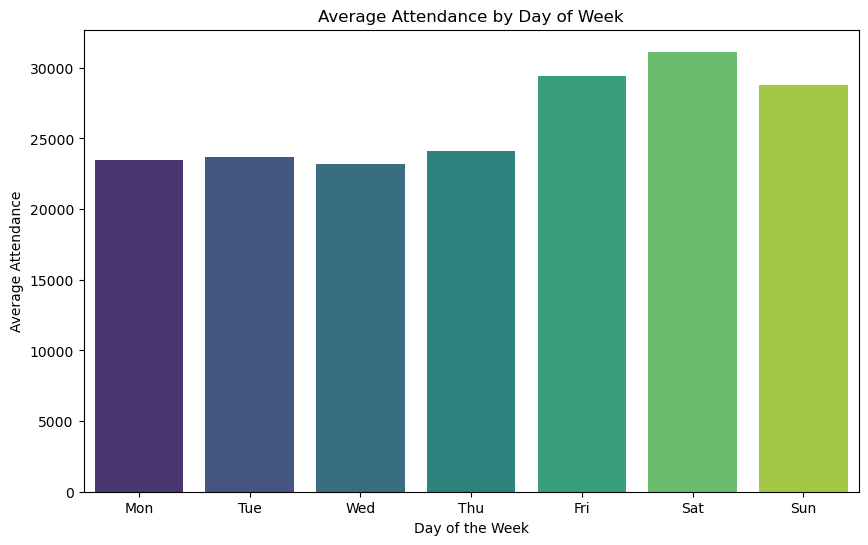

In [30]:
# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=day_attendance.index, y=day_attendance.values, palette='viridis')
plt.title('Average Attendance by Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Attendance')
plt.show()

-> 데이터를 보면 금요일(Fri)의 관중 수가 약 29,419명으로, 월~목(23,000~24,000명 대)보다 확연히 높고 일요일(약 28,774명)보다도 높음.  
MLB에서 금요일 경기가 사실상 '주말권'에 완전히 포함된다는 것을 나타냄. 퇴근 후 경기를 즐기러 오는 관중이 일요일 낮 경기 관중보다 더 많다는 것. 
따라서 금요일을 '평일'로 묶기보다는 '주말'로 묶어야함. 

In [31]:
game['is_weekend'] = game['day_of_week'].apply(lambda x: 1 if x >= 4 else 0)

In [32]:
game['is_weekend'].value_counts()

is_weekend
0    6189
1    5964
Name: count, dtype: int64

In [33]:
game.head()

,gid,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,...,wteam,lteam,season,Season,season_spring,season_summer,season_autumn,day_of_week,day_name,is_weekend
0,ANA202104010,CHA,ANA,ANA01,2021-04-01,0,7:05PM,night,9,2.0,...,ANA,CHA,2021,Spring/Early,1,0,0,3,Thu,0
1,CHN202104010,PIT,CHN,CHI11,2021-04-01,0,1:20PM,day,9,2.0,...,PIT,CHN,2021,Spring/Early,1,0,0,3,Thu,0
2,CIN202104010,SLN,CIN,CIN09,2021-04-01,0,4:10PM,day,9,2.0,...,SLN,CIN,2021,Spring/Early,1,0,0,3,Thu,0
3,COL202104010,LAN,COL,DEN02,2021-04-01,0,2:10PM,day,9,2.0,...,COL,LAN,2021,Spring/Early,1,0,0,3,Thu,0
4,DET202104010,CLE,DET,DET05,2021-04-01,0,1:10PM,day,9,2.0,...,DET,CLE,2021,Spring/Early,1,0,0,3,Thu,0


--- 마이애미 말린스 요일별 승률 ---
day_name
Mon    0.282353
Tue    0.411290
Wed    0.488000
Thu    0.466667
Fri    0.371212
Sat    0.510791
Sun    0.538462
Name: mia_win, dtype: float64


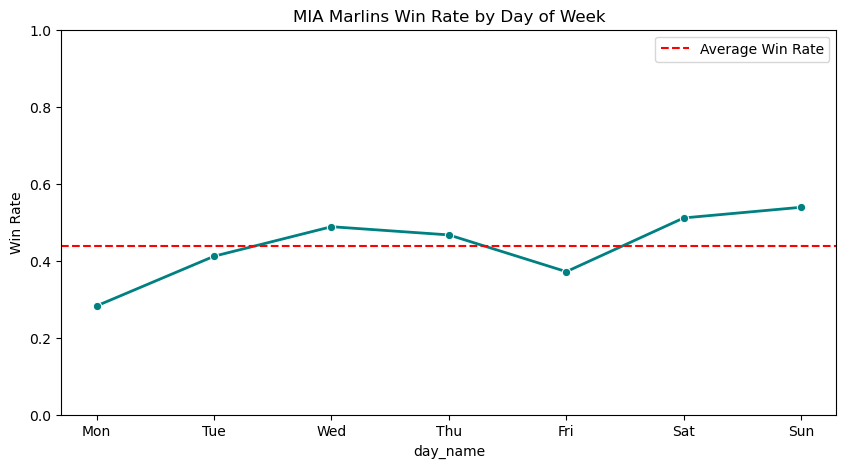

In [34]:
# 마이애미 요일별 승률 확인하기 

# 1. 마이애미(MIA)가 이긴 경기인지 여부를 확인하는 컬럼 생성
# wteam 컬럼 값이 'MIA'이면 승리(1), 아니면 패배(0)
game['mia_win'] = (game['wteam'] == 'MIA').astype(int)

# 2. 마이애미가 참여한 경기만 필터링 (홈팀 혹은 원정팀이 MIA인 경우)
mia_games = game[(game['hometeam'] == 'MIA') | (game['visteam'] == 'MIA')].copy()

# 3. 요일별 승률 계산
mia_win_rate = mia_games.groupby('day_name')['mia_win'].mean().reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

print("--- 마이애미 말린스 요일별 승률 ---")
print(mia_win_rate)

# 4. 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(x=mia_win_rate.index, y=mia_win_rate.values, marker='o', color='teal', linewidth=2)
plt.axhline(mia_win_rate.mean(), color='red', linestyle='--', label='Average Win Rate') # 평균 승률 선
plt.title('MIA Marlins Win Rate by Day of Week')
plt.ylabel('Win Rate')
plt.ylim(0, 1) # 승률은 0~1 사이
plt.legend()
plt.show()


**요일별 승률과 이전에 확인한 관중 수 데이터를 비교한 결과** 

**금요일의 역설**:  
관중: 약 2.96만 명 (전체 요일 중 2위, 급증 구간)   
승률: 0.371 (평균 이하, 평일인 수·목요일보다 확연히 낮음)   
해석: 금요일은 관중이 대거 몰리는 '주말권'임에도 불구하고 승률이 급락 -> 홈 팬들의 기대치에 비해 경기력이 가장 안 나오는 요일   

**진정한 주말의 강세**:  
토요일(0.511)과 일요일(0.538)은 마이애미가 가장 강한 모습을 보이는 구간->  관중이 가장 많은 토요일에 승률이 5할을 넘긴다는 점은 긍정적임.  

**월요일의 저점**:  
승률이 0.282로 최악임. 이동일 직후나 시리즈 시작점에서 팀 컨디션 조절에 큰 문제를 겪고 있을 가능성이 높음. 

---
## **number**  
- 투수 운용과 불펜 소모도, 그리고 관중의 집중도 측면에서 아주 중요한 변수  
- 더블헤더(Doubleheader)는 하루에 두 경기를 치러야 하므로 팀의 자원 관리 전략이 완전히 달라짐.  

**파생 변수 생성**  
- 단일 경기→ 0,  1-3차전→ 1 인 more_game 변수 생성

In [35]:
game['number'].value_counts()

number
0    11713
1      220
2      220
Name: count, dtype: int64

In [36]:
# number가 0이면 0(단일 경기), 1이나 2면 1(더블헤더)로 변환
game['more_game'] = game['number'].apply(lambda x: 0 if x == 0 else 1)

# 생성 결과 확인 (더블헤더 경기 수 확인)
print(game['more_game'].value_counts())

more_game
0    11713
1      440
Name: count, dtype: int64


---
## **daynight**
- 심리적/신체적 안정감: 대부분의 경기가 야간에 열리기 때문에, 선수들은 야간 경기에 더 익숙하고 심리적으로 안정된 상태에서 경기에 임하는 경우가 많음 
- 시야 및 집중력: 낮 경기, 특히 해 질 녘 시간대는 태양 위치에 따라 공의 궤적을 인지하기 어려울 수 있으며, 낮과 밤의 조명 환경 차이가 타격과 수비의 시야에 영향을 줌
- 온도 변화에 따른 컨디션: 일교차가 큰 가을 야구 등에서는 낮 경기에서 밤 경기로 바뀔 때 기온 급강하로 인해 선수들의 체감 온도가 15도 이상 차이 나기도 하여 부상 위험이 증가  

In [37]:
game['is_night'] = game['daynight'].map({'day': 0, 'night': 1})

# 인코딩 결과 확인
print(game['is_night'].value_counts())

is_night
1    7586
0    4567
Name: count, dtype: int64


--- 마이애미 말린스 주간/야간 승률 ---
daynight
day      0.482540
night    0.422222
Name: mia_win, dtype: float64


C:\Users\강태희\AppData\Local\Temp\ipykernel_16652\3541716404.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daynight_win_rate.index, y=daynight_win_rate.values, palette='coolwarm')


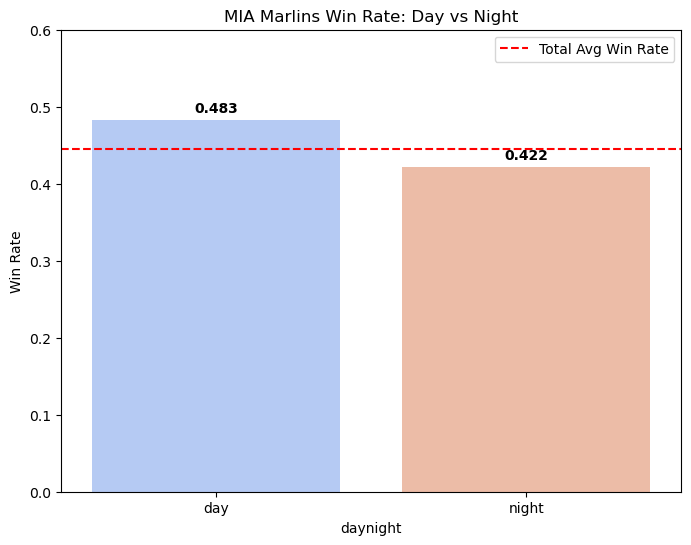

In [38]:
# 마이애미(MIA) 주간/야간 승률 분석 및 시각화
# 1. 마이애미 경기 필터링 
mia_games = game[(game['hometeam'] == 'MIA') | (game['visteam'] == 'MIA')].copy()

# 2. 주간/야간별 승률 계산
# 'daynight' 문자열을 기준으로 그룹화하여 승률 평균 계산
daynight_win_rate = mia_games.groupby('daynight')['mia_win'].mean()

print("--- 마이애미 말린스 주간/야간 승률 ---")
print(daynight_win_rate)

# 3. 시각화

plt.figure(figsize=(8, 6))
sns.barplot(x=daynight_win_rate.index, y=daynight_win_rate.values, palette='coolwarm')

# 평균 승률 가이드라인
plt.axhline(mia_games['mia_win'].mean(), color='red', linestyle='--', label='Total Avg Win Rate')

plt.title('MIA Marlins Win Rate: Day vs Night')
plt.ylabel('Win Rate')
plt.ylim(0, 0.6)
for i, v in enumerate(daynight_win_rate.values):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.legend()
plt.show()

야간 경기보다 주간 경기에서의 승률이 더 높음을 확인함  
앞서 확인했던 '금요일 승률 저하' 현상의 원인이 '야간 경기' 때문일 가능성이 더 커짐  
금요일은 100% 야간 경기 -> 마이애미는 관중이 가장 많이 몰리는 야간 시간대에 유독 약한 모습을 보이고 있음 

---
## **innings**

In [39]:
game['innings'].value_counts()

innings
9    12032
7      121
Name: count, dtype: int64

- Innings 9 : 표준적인 야구 경기.
- Innings 7 : 더블헤더 특별 규정이 적용된 경기  
   MLB는 2020년과 2021년에 선수들의 체력 보호와 일정 소화를 위해 더블헤더 경기를 7이닝제로 운영함.  
   일반 경기보다 경기 시간이 짧고 투수 운용 전략이 완전히 달랐던 데이터임. 

7이닝 경기는 9이닝 경기보다 당연히 전체 안타, 득점, 탈삼진 수가 적을 수밖에 없음  
분석에 사용할 시 단순히 '저득점 경기' 군집으로 잘못 분류될 수 있음  
단순히 innings > 9로만 연장전을 정의하면, **7이닝 시대의 연장전(8, 9이닝 경기)** 을 놓침, 반대로 9이닝 시대의 더블헤더는 연장전이 아닌데도 이닝 수만 봐서는 구분이 안됨  
-> **행 삭제** + innings 컬럼 삭제

In [40]:
game.shape

(12153, 35)

In [41]:
# innings가 7이 아닌 데이터만 남기기
game = game[game['innings'] != 7]

# 인덱스 재정렬
game = game.reset_index(drop=True)

In [42]:
game.shape

(12032, 35)

In [43]:
# innings 컬럼 삭제
game = game.drop(columns=['innings'])

In [44]:
game.columns

Index(['gid', 'visteam', 'hometeam', 'site', 'date', 'number', 'starttime',
       'daynight', 'tiebreaker', 'usedh', 'timeofgame', 'attendance', 'sky',
       'temp', 'winddir', 'windspeed', 'wp', 'lp', 'save', 'vruns', 'hruns',
       'wteam', 'lteam', 'season', 'Season', 'season_spring', 'season_summer',
       'season_autumn', 'day_of_week', 'day_name', 'is_weekend', 'mia_win',
       'more_game', 'is_night'],
      dtype='object')

---
## **tiebreaker**

- MLB(메이저리그)의 연장전 승부치기(Ghost Runner/Tie-breaker) 룰은 2020년 시범 도입 후 정착

In [45]:
game['tiebreaker'].value_counts()

tiebreaker
2.0    12029
Name: count, dtype: int64

In [46]:
game['tiebreaker'].isna().sum()

3

**결측치 3개를 제외하고는 모두 값이 2로 동일함 -> tiebreaker 컬럼 삭제**

In [47]:
# 값이 모두 동일하여 변수로서 의미가 없으므로 삭제
game = game.drop(columns=['tiebreaker'])

In [48]:
game.shape

(12032, 33)

----

### 중간 저장 

In [49]:
game.to_csv('MLB_gameinfo.csv', index=False)

---
## **usedh**
지명타자(DH) 제도를 사용했는지 여부

In [50]:
game['usedh'].value_counts()

usedh
True     10880
False     1152
Name: count, dtype: int64

In [51]:
# 기존 usedh 컬럼의 True/False를 1/0으로 변환
game = game.assign(usedh = game['usedh'].astype(int))

In [52]:
game['usedh'].value_counts()

usedh
1    10880
0     1152
Name: count, dtype: int64

---
## **time of game**

<Axes: ylabel='timeofgame'>

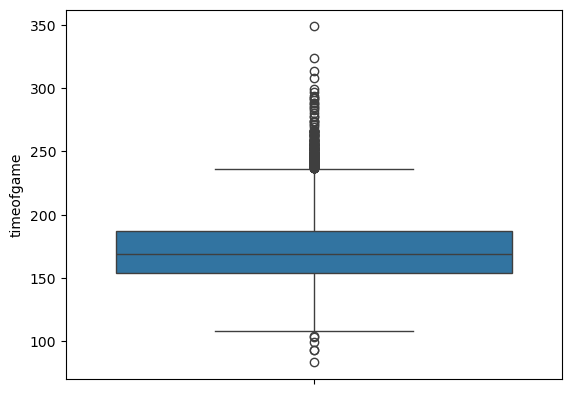

In [53]:
sns.boxplot(game['timeofgame'])

In [54]:
game.query('timeofgame >= 300')

,gid,visteam,hometeam,site,date,number,starttime,daynight,usedh,timeofgame,...,Season,season_spring,season_summer,season_autumn,day_of_week,day_name,is_weekend,mia_win,more_game,is_night
718,HOU202105290,SDN,HOU,HOU03,2021-05-29,0,3:10PM,day,1,308,...,Spring/Early,1,0,0,5,Sat,1,0,0,0
1014,MIN202106210,CIN,MIN,MIN04,2021-06-21,0,7:10PM,night,1,314,...,Summer/Mid,0,1,0,0,Mon,0,0,0,1
1796,SDN202108250,LAN,SDN,SAN02,2021-08-25,0,7:10PM,night,0,349,...,Summer/Mid,0,1,0,2,Wed,0,0,0,1
4479,CLE202209172,MIN,CLE,CLE08,2022-09-17,2,7:10PM,night,1,324,...,Autumn/Late,0,0,1,5,Sat,1,0,1,1


In [55]:
# 기초 통계량 확인
print(game['timeofgame'].describe())

count    12032.000000
mean       172.204205
std         25.902150
min         83.000000
25%        154.000000
50%        169.000000
75%        187.000000
max        349.000000
Name: timeofgame, dtype: float64


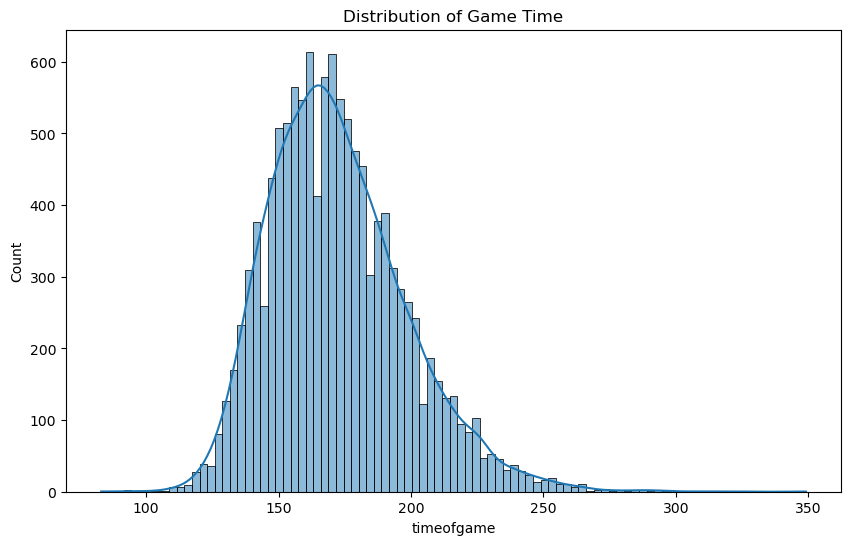

In [56]:
# 분포 시각화
plt.figure(figsize=(10, 6))
sns.histplot(game['timeofgame'], kde=True)
plt.title('Distribution of Game Time')
plt.show()

평균(172)과 중앙값(169)이 거의 비슷함.  
 그래프를 보았을 때 데이터가 비교적 대칭적이므로 굳이 로그나 제곱근 변환을 하지 않고 수치형 데이터 그대로 스케일링만 진행

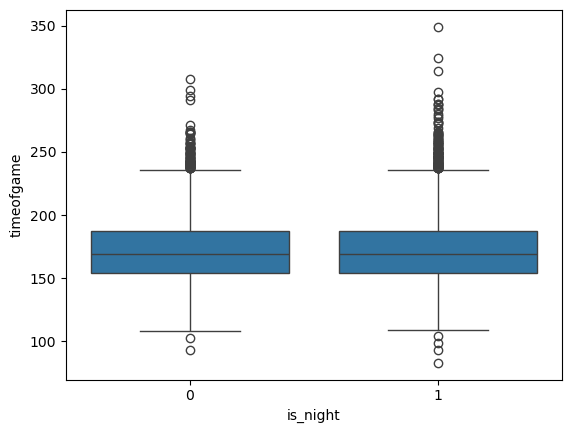

In [57]:
# 야간/주간 경기 시간에 따른 차이 확인
sns.boxplot(x='is_night', y='timeofgame', data=game)
plt.show()

---
## **attendance**

In [58]:
game['attendance'].describe()

count    12032.000000
mean     26769.012134
std      11915.574580
min          0.000000
25%      17073.750000
50%      27319.500000
75%      36394.500000
max      91032.000000
Name: attendance, dtype: float64

<Axes: ylabel='attendance'>

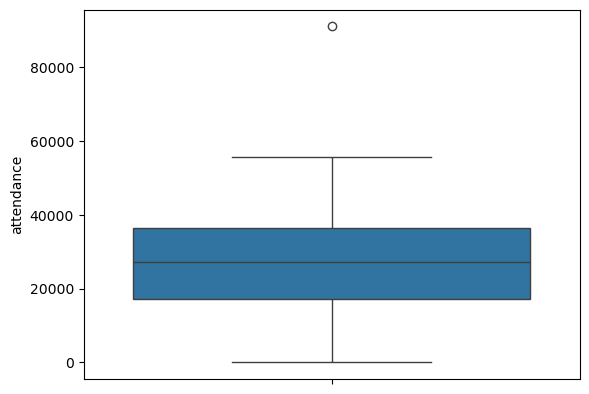

In [59]:
sns.boxplot(game['attendance'])

In [62]:
max_attendance_game = game[game['attendance'] == game['attendance'].max()]
max_attendance_game

,gid,visteam,hometeam,site,date,number,starttime,daynight,usedh,timeofgame,...,Season,season_spring,season_summer,season_autumn,day_of_week,day_name,is_weekend,mia_win,more_game,is_night
11256,CIN202508020,ATL,CIN,BST01,2025-08-02,0,1:05PM,day,1,161,...,Summer/Mid,0,1,0,5,Sat,1,0,0,0


CIN202508020 경기는 메이저리그 역사상 정규 시즌 최다 관중 기록을 경신한 기념비적인 이벤트
'MLB 스피드웨이 클래식(Speedway Classic)'

**이 경기가 특별했던 이유**
- 장소의 특수성: 일반 야구장이 아닌, 세계적인 자동차 경주장인 테네시주의 브리스틀 모터 스피드웨이(Bristol Motor Speedway) 내부에 임시 야구장을 건설하여 개최됨 
- 역사적 의미: 테네시주에서 열린 사상 첫 메이저리그 정규 시즌 경기였음

이 경기는 "야구장"이 아닌 "레이싱 트랙"에서 열렸기에 그런 비정상적인 관중 숫자가 가능했던 것-> 삭제하기 

In [67]:
game = game[game['attendance'] != 91032]

In [68]:
game.shape

(12031, 33)

In [65]:
# 최소 관중을 기록한 경기 출력
min_attendance_game = game[game['attendance'] == game['attendance'].min()]
min_attendance_game

,gid,visteam,hometeam,site,date,number,starttime,daynight,usedh,timeofgame,...,Season,season_spring,season_summer,season_autumn,day_of_week,day_name,is_weekend,mia_win,more_game,is_night
2468,NYN202204191,SFN,NYN,NYC20,2022-04-19,1,3:10PM,day,1,213,...,Spring/Early,1,0,0,1,Tue,0,0,1,0
2477,CLE202204201,CHA,CLE,CLE08,2022-04-20,1,2:10PM,day,1,161,...,Spring/Early,1,0,0,2,Wed,0,0,1,0
2658,NYN202205031,ATL,NYN,NYC20,2022-05-03,1,3:10PM,day,1,169,...,Spring/Early,1,0,0,1,Tue,0,0,1,0
2666,CLE202205041,SDN,CLE,CLE08,2022-05-04,1,1:10PM,day,1,195,...,Spring/Early,1,0,0,2,Wed,0,0,1,0
2669,DET202205041,PIT,DET,DET05,2022-05-04,1,1:10PM,day,1,161,...,Spring/Early,1,0,0,2,Wed,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10137,WAS202505061,CLE,WAS,WAS11,2025-05-06,1,3:35PM,day,1,172,...,Spring/Early,1,0,0,1,Tue,0,0,1,0
10158,COL202505081,DET,COL,DEN02,2025-05-08,1,1:10PM,day,1,140,...,Spring/Early,1,0,0,3,Thu,0,0,1,0
10233,BAL202505141,MIN,BAL,BAL12,2025-05-14,1,12:05PM,day,1,181,...,Spring/Early,1,0,0,2,Wed,0,0,1,0
10307,MIN202505190,CLE,MIN,MIN04,2025-05-19,0,12:10PM,day,1,169,...,Spring/Early,1,0,0,0,Mon,0,0,0,0


**관중수가 0으로 기록된 경기 해석**
- 대부분 number 컬럼의 값이 1 또는 2로 되어 있는 경기들임
- MLB의 관중 집계 관행: 하루에 두 경기를 치르는 더블헤더의 경우, 1차전과 2차전 관중을 합쳐서 한 경기에만 몰아서 기록, 통합 입장권을 팔기에 한 경기는 0으로 처리하고 다른 한 경기에 전체 관중 수를 넣는 경우가 굉장히 흔함  
-> **홈팀별 관중 수의 중앙값으로 대체**

In [69]:
# 홈팀별 관중 수 중앙값으로 채우기
game['attendance'] = game['attendance'].replace(0, np.nan)

# 홈팀별로 그룹화하여 해당 팀의 관중 수 중앙값으로 결측치를 채우기 
game['attendance'] = game.groupby('hometeam')['attendance'].transform(lambda x: x.fillna(x.median()))

In [70]:
game['attendance'].isna().sum()

0

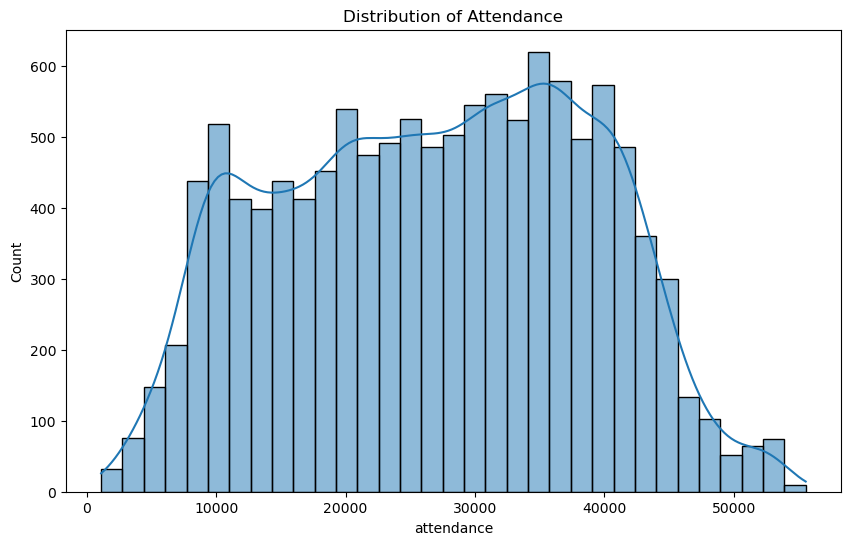

In [72]:
# 분포 시각화
plt.figure(figsize=(10, 6))
sns.histplot(game['attendance'], kde=True)
plt.title('Distribution of Attendance')
plt.show()

---
## **sky**

- 실내(Dome) vs 실외(Outdoor) 구분: 돔구장은 날씨(바람, 습도, 햇빛)의 영향을 받지 않기 때문에 경기 기록에 큰 차이를 만듦  
- 기상 상태의 '가혹도' (Weather Intensity): 클러스터링 시 "날씨가 경기에 얼마나 방해가 되었나?"를 수치화  
  -> sunny: 0 (매우 쾌적)/ cloudy: 1 (보통)/ overcast: 2 (매우 흐림, 비 올 확률 높음)/ dome: 0 (통제된 환경이므로 쾌적한 상태로 간주하거나 별도 처리)

In [73]:
game['sky'].value_counts()

sky
cloudy      5287
sunny       3846
dome        2120
overcast     776
unknown        2
Name: count, dtype: int64

In [74]:
game.query('sky=="unknown"')

,gid,visteam,hometeam,site,date,number,starttime,daynight,usedh,timeofgame,...,Season,season_spring,season_summer,season_autumn,day_of_week,day_name,is_weekend,mia_win,more_game,is_night
1274,NLS202107130,ALS,NLS,DEN02,2021-07-13,0,5:30PM,night,1,180,...,Summer/Mid,0,1,0,1,Tue,0,0,0,1
7518,KCA202404230,TOR,KCA,KAN06,2024-04-23,0,6:40PM,night,1,153,...,Spring/Early,1,0,0,1,Tue,0,0,0,1


In [75]:
# sky 컬럼이 'unknown'인 행들 삭제 
game = game[game['sky'] != 'unknown']

# 삭제 후 확인 
print(game['sky'].value_counts())

sky
cloudy      5287
sunny       3846
dome        2120
overcast     776
Name: count, dtype: int64


In [76]:
# 실외, 실내 구분 파생변수 생성 
game = game.assign(is_dome = (game['sky'] == 'dome').astype(int))

In [77]:
game['is_dome'].value_counts()

is_dome
0    9909
1    2120
Name: count, dtype: int64

In [78]:
# 기상 상태의 가혹도를 나타내는 변수 생성 
weather_map = {'sunny': 0, 'cloudy': 1, 'overcast': 2, 'dome': 0, 'unknown': 1}
game['weather_severity'] = game['sky'].map(weather_map)

In [79]:
game['weather_severity'].value_counts()

weather_severity
0    5966
1    5287
2     776
Name: count, dtype: int64

---
## **winddir**
방향 가중치 파생변수 생성 
- +1 (타자 유리): tocf (중앙 외야로), torf (우측 외야로), tolf (좌측 외야로)
- -1 (투수 유리): fromcf (중앙에서 홈으로), fromrf (우측에서 홈으로), fromlf (좌측에서 홈으로)
- 0 (중립/무영향): ltor (왼쪽에서 오른쪽), rtol (오른쪽에서 왼쪽), unknown (정보 없음)

In [80]:
game['winddir'].value_counts()

winddir
unknown    2738
ltor       1789
tocf       1482
rtol       1431
torf       1259
tolf       1148
fromlf      842
fromrf      705
fromcf      635
Name: count, dtype: int64

In [81]:
# 바람 방향 매핑 딕셔너리 생성
wind_map = {
    # 타자 유리 
    'tocf': 1, 'torf': 1, 'tolf': 1,
    
    # 투수 유리 
    'fromcf': -1, 'fromrf': -1, 'fromlf': -1,
    
    # 중립 또는 횡풍
    'ltor': 0, 'rtol': 0, 'unknown': 0
}

# 파생변수 생성
game['dir_weight'] = game['winddir'].map(wind_map)

# 결과 확인
print(game['dir_weight'].value_counts())

dir_weight
 0    5958
 1    3889
-1    2182
Name: count, dtype: int64


---
## **windspeed**
- 바람의 영향력 지수: dir_weight * windspeed 변수 생성

In [82]:
game['windspeed'].dtypes

dtype('int64')

In [83]:
game['wind_impact'] = game['dir_weight'] * game['windspeed']

In [84]:
print(game[['winddir', 'windspeed', 'dir_weight', 'wind_impact']].head())

  winddir  windspeed  dir_weight  wind_impact
0    tocf          6           1            6
1    ltor          7           0            0
2    torf         16           1           16
3    tocf          5           1            5
4    tocf         15           1           15


---
## **vruns**

- 득실점 차 변수-> 팀의 클러치 능력을 평가하는 데 핵심적인 지표. 특히 1점 차 승부에서의 승률은 팀의 불펜 투수력과 작전 수행 능력을 보여줌 

In [85]:
# 득실점 차이의 절대값 생성
game['run_diff'] = abs(game['vruns'] - game['hruns'])

In [86]:
# MIA 팀의 득실점 차이 및 박빙 승부 분석
mia_games['run_diff'] = abs(mia_games['vruns'] - mia_games['hruns'])

# 3. 마이애미의 1점 차 경기(박빙)만 추출
mia_clutch_games = mia_games[mia_games['run_diff'] == 1]

# 4. 1점 차 승률 계산 (mia_win의 평균)
clutch_win_rate = mia_clutch_games['mia_win'].mean()
clutch_count = len(mia_clutch_games)

print(f"마이애미의 전체 경기 수: {len(mia_games)}경기")
print(f"마이애미의 1점 차(박빙) 경기 수: {clutch_count}경기")
print(f"마이애미의 1점 차 승률: {clutch_win_rate:.2%}")

마이애미의 전체 경기 수: 810경기
마이애미의 1점 차(박빙) 경기 수: 248경기
마이애미의 1점 차 승률: 49.60%


- 비중 분석: 전체 810경기 중 248경기가 1점 차 승부였다는 것은, 마이애미 경기의 약 30%가 마지막까지 승부를 알 수 없는 긴박한 상황이었다는 뜻임.  
- 클러스터링 시사점: 군집 분석을 하면 마이애미는 '저득점-접전' 군집에 상당히 많은 데이터가 쏠려 있을 가능성이 높음.

In [87]:
# 시즌별 1점 차 승부 승률 비교
season_clutch = mia_games[mia_games['run_diff'] == 1].groupby('season')['mia_win'].mean()
print(season_clutch)

season
2021    0.420000
2022    0.375000
2023    0.702128
2024    0.534884
2025    0.500000
Name: mia_win, dtype: float64


1점 차 승부 군집에서 마이애미의 승률은 평균 49%이지만, 2023년만 떼어놓고 보면 이 군집에서 압도적 승률을 기록했음 

**2023년의 마이애미 말린스**
- 2023년 마이애미 말린스는 84승 76패를 기록하며 예상을 뒤엎고 3년 만에 포스트시즌(와일드카드) 진출에 성공한 성공적인 시즌을 보냈음 
- 6월 이후 상승세를 타며 와일드카드 순위 1위를 기록했고, 풀시즌 기준으로 20년 만에 가을야구 입성
- 미네소타로부터 루이스 아라에즈(Luis Arráez)를 트레이드해왔음 -> 아라에즈는 그해 타율 .354를 기록하며 타격왕을 차지함.  
  점수가 많이 나지 않는 접전 상황에서 마이애미가 결승점을 뽑아내는 데 결정적인 역할을 했음. 


In [89]:
game.head()

,gid,visteam,hometeam,site,date,number,starttime,daynight,usedh,timeofgame,...,day_name,is_weekend,mia_win,more_game,is_night,is_dome,weather_severity,dir_weight,wind_impact,run_diff
0,ANA202104010,CHA,ANA,ANA01,2021-04-01,0,7:05PM,night,1,171,...,Thu,0,0,0,1,0,1,1,6,1
1,CHN202104010,PIT,CHN,CHI11,2021-04-01,0,1:20PM,day,0,240,...,Thu,0,0,0,0,0,0,0,0,2
2,CIN202104010,SLN,CIN,CIN09,2021-04-01,0,4:10PM,day,0,211,...,Thu,0,0,0,0,0,1,1,16,5
3,COL202104010,LAN,COL,DEN02,2021-04-01,0,2:10PM,day,0,226,...,Thu,0,0,0,0,0,0,1,5,3
4,DET202104010,CLE,DET,DET05,2021-04-01,0,1:10PM,day,1,183,...,Thu,0,0,0,0,0,2,1,15,1


In [90]:
# 저장 
game.to_csv('MLB_allgameinfo.csv', index=False)